# SE Factory AIE Bootcamp — Week 6, Day 2
## Training a Neural Network: PyTorch, Autograd, Real Optimisers

**Objective:** Take yesterday's hand-rolled MLP and rewrite it in
PyTorch. Verify it produces *byte-identical* predictions on the same
weights (~3.6e-7 agreement, the residual is float arithmetic noise
across BLAS implementations), then upgrade to the 37-class breed
problem with Adam, LR scheduling, and early stopping. The honest
finding tonight: a tiny MLP on 32x32 grayscale flattened pixels
manages ~7% test top-1 (vs 2.7% random) — better than chance, but
Adam alone doesn't rescue this representation. The lesson is what
PyTorch *adds* (autograd, optimisers, schedulers); the bigger
leaps come tomorrow (CNN, +9pp) and Thursday (pretraining, +71pp).

**Dataset:** Oxford-IIIT Pet (37 breeds). Yesterday we collapsed
breeds to cat/dog binary; tonight we use the full 37-class target.

**Picks up from yesterday's:** day-1 MLP weights saved as
`week6_day1_mlp_weights.npz`. Section 2's recap re-downloads the
dataset, reproduces the train/val/test split, and (if the file is
present) optionally loads day 1's trained weights for the byte-
identical comparison in Section 4.

**Self-contained:** torchvision downloads Pets fresh into `/content/`.
Day 1's `.npz` artifact is *optional* — if missing, Section 4's
diagnostic is skipped but training still proceeds.

**What this notebook adds over day 1:** `torch.nn.Module` (the
architecture as an object), `torch.optim` (real optimisers), GPU
placement, `torch.utils.data.DataLoader` (proper batching), LR
scheduling, early stopping, multi-class cross-entropy. The math
from yesterday is unchanged; PyTorch automates the bookkeeping.

## 0) Environment bootstrap

In [ ]:
import subprocess, sys

def _ensure(spec, import_name=None):
    name = import_name or spec.split('==')[0].split('<')[0].split('>')[0].strip()
    try:
        __import__(name)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', spec])

_ensure('torch')
_ensure('torchvision')
_ensure('Pillow', 'PIL')

print("Bootstrap complete.")

Bootstrap complete.


### Instructor Notes — Bootstrap

**Code:** Same `_ensure` helper as yesterday. Installs (or no-ops on)
torch, torchvision, Pillow. Colab ships all three pre-installed; on
a stripped runtime you'd see ~1-2 minutes of pip downloads.

**Expected output:** `Bootstrap complete.`

**Why no version pin?** Day 2 produces no joblib for downstream
days to load. Each day downloads the dataset fresh from torchvision
and trains its own model. With no pickled object whose
deserialisation depends on a specific version, version pinning
isn't load-bearing. (Tomorrow's notebook will save its trained
model as a `.pt` file — and at that point we *will* pin the torch
version, because PyTorch state-dicts are version-coupled the way
sklearn pickles are.)

**Common mistake:** Pinning `torch==2.0.x` because it's what your
local machine has. Colab runtimes update torch every few months;
pinning to a stale version forces a reinstall on every cold runtime
— slow and wasteful. Trust Colab's default unless you have a
specific reason to deviate.

**Discussion prompt:** "What changes about the bootstrap when we
move to a paid Colab runtime with a GPU?" → Nothing in this cell.
The torch wheel Colab ships includes CUDA support automatically;
a paid GPU runtime just makes `.cuda()` calls do something useful.
We'll see this in Section 1 when we set the device.

## 1) Setup and Imports

In [ ]:
import math
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import torchvision

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch={torch.__version__}  device={DEVICE}")
print(f"Seed set to {SEED}")

torch=2.10.0+cu128  device=cuda
Seed set to 42


### Instructor Notes — Imports, seed, device

**Code:** Imports all four NumPy / matplotlib / PIL / torchvision as
yesterday, *plus* PyTorch and four of its standard sub-modules:
`torch.nn` (layers + losses), `torch.nn.functional` (functional
APIs that don't carry parameters, e.g. `F.cross_entropy`),
`torch.utils.data.DataLoader` and `TensorDataset` (the standard
batching pipeline). Seeds *every* random source — Python's,
NumPy's, PyTorch's CPU RNG, and (if available) PyTorch's CUDA RNG.
Detects GPU availability and binds `DEVICE`.

**Expected output:**
- `torch=2.x  device=cuda` (Colab GPU runtime) or `device=cpu` (free runtime).
- `Seed set to 42`.

**Why seed *all four* RNGs?** Different operations consume
different RNGs. `np.random.choice` uses NumPy's; `torch.randn`
uses PyTorch's CPU; `nn.Dropout` on GPU uses PyTorch's CUDA RNG.
Seeding only one gives you reproducibility *for some operations*
and silent randomness for others. The bug is invisible until
someone re-runs your notebook on a different machine and gets
different results.

**Why `torch.cuda.manual_seed_all`?** PyTorch keeps separate RNG
state per CUDA device. With multi-GPU runtimes (Colab Pro+
sometimes provides them), `manual_seed_all` seeds every visible
GPU; `manual_seed` seeds only the current one. Defensive
programming — costs nothing if there's no GPU, prevents weird
bugs if there is.

**Why bind `DEVICE` once and reuse?** Two reasons. (1) Style: every
`.to(DEVICE)` in this notebook reads the same way, regardless of
the runtime. (2) Performance: changing devices mid-training (CPU
for one batch, GPU for the next) involves expensive memcopies
across the PCI-E bus. Bind once, train on one device, never move.

**Common mistake:** Forgetting to call `.to(DEVICE)` on either the
model *or* the inputs. PyTorch errors out with `RuntimeError:
Expected all tensors to be on the same device` — clear message,
but a frustrating one if you've been training for 5 minutes
before hitting it. Defensive: move the model to DEVICE right
after instantiation; move each batch to DEVICE inside the
training loop.

**Discussion prompt:** "If we ran the notebook on CPU instead of
GPU, what would change?" → Speed only. Tonight's MLP is small
enough that CPU training takes ~30 seconds for 30 epochs;
GPU is ~5 seconds. The math is identical, the API is identical,
the metrics are identical. GPU shines on Wednesday's CNNs and
Thursday's pretrained models — tonight's lift from GPU is
modest.

## 2) Recap of day 1: re-download Pets, reproduce splits, (optionally) load day-1 weights
Make sure the npz weights file is on the colab environment files

In [ ]:
# --- 2a) Download Oxford-IIIT Pets (cached after first run). ---
DATA_ROOT = Path("/content/oxford-pets")
DATA_ROOT.mkdir(parents=True, exist_ok=True)
train_split = torchvision.datasets.OxfordIIITPet(
    root=str(DATA_ROOT), split="trainval", target_types="category", download=True,
)
test_split = torchvision.datasets.OxfordIIITPet(
    root=str(DATA_ROOT), split="test", target_types="category", download=True,
)
print(f"trainval images: {len(train_split)}  test: {len(test_split)}  classes: {len(train_split.classes)}")

# --- 2b) Build (path, label) lists. Two label spaces:
#         - binary (0=cat, 1=dog) — matches yesterday for the diagnostic
#         - multi-class (0..36 breed) — tonight's target
CAT_BREEDS = set(range(0, 12))
def to_binary(c): return 0 if c in CAT_BREEDS else 1
def collect(ds, label_fn):
    return [(str(p), int(label_fn(int(c)))) for p, c in zip(ds._images, ds._labels)]

train_items_bin   = collect(train_split, to_binary)
test_items_bin    = collect(test_split,  to_binary)
train_items_multi = collect(train_split, lambda c: c)  # raw breed
test_items_multi  = collect(test_split,  lambda c: c)

# --- 2c) Image -> 1024-D vector (same as yesterday). ---
IMG_SIZE = 32
def image_to_vector(path):
    img = Image.open(path).convert("L").resize((IMG_SIZE, IMG_SIZE))
    return np.asarray(img, dtype=np.float32).flatten() / 255.0

def materialise(items):
    X = np.empty((len(items), IMG_SIZE * IMG_SIZE), dtype=np.float32)
    y = np.empty(len(items), dtype=np.int64)
    for i, (p, lab) in enumerate(items):
        X[i] = image_to_vector(p)
        y[i] = lab
    return X, y

X_full_bin,   y_full_bin   = materialise(train_items_bin)
X_test_bin,   y_test_bin   = materialise(test_items_bin)
X_full_multi, y_full_multi = materialise(train_items_multi)
X_test_multi, y_test_multi = materialise(test_items_multi)

# --- 2d) Same stratified 80/20 split as yesterday (same seed). ---
def stratified_split(X, y, val_frac=0.20, seed=SEED):
    rng = np.random.default_rng(seed)
    classes = np.unique(y)
    tr_idx_list, va_idx_list = [], []
    for c in classes:
        cls_idx = np.where(y == c)[0]
        rng.shuffle(cls_idx)
        cut = int(len(cls_idx) * (1 - val_frac))
        tr_idx_list.append(cls_idx[:cut])
        va_idx_list.append(cls_idx[cut:])
    tr = np.concatenate(tr_idx_list); va = np.concatenate(va_idx_list)
    rng.shuffle(tr); rng.shuffle(va)
    return X[tr], y[tr], X[va], y[va]

X_tr_bin,   y_tr_bin,   X_va_bin,   y_va_bin   = stratified_split(X_full_bin,   y_full_bin)
X_tr_multi, y_tr_multi, X_va_multi, y_va_multi = stratified_split(X_full_multi, y_full_multi)

print(f"binary  | train {X_tr_bin.shape[0]}  val {X_va_bin.shape[0]}  test {X_test_bin.shape[0]}")
print(f"multi-37| train {X_tr_multi.shape[0]}  val {X_va_multi.shape[0]}  test {X_test_multi.shape[0]}")

# --- 2e) Try to load day-1 weights for the byte-identical diagnostic. ---
DAY1_WEIGHTS = Path("/content/week6_day1_mlp_weights.npz")
if DAY1_WEIGHTS.exists():
    day1 = np.load(DAY1_WEIGHTS)
    print(f"day-1 weights present:  W1 {day1['W1'].shape}, W2 {day1['W2'].shape}, "
          f"test_acc={float(day1['test_acc'][0]):.4f}")
else:
    day1 = None
    print("day-1 weights NOT present — Section 4 byte-identical check will be skipped.")

100%|██████████| 792M/792M [00:03<00:00, 241MB/s]
100%|██████████| 19.2M/19.2M [00:00<00:00, 128MB/s] 


trainval images: 3680  test: 3669  classes: 37
binary  | train 2943  val 737  test 3669
multi-37| train 2941  val 739  test 3669
day-1 weights present:  W1 (1024, 64), W2 (64, 1), test_acc=0.6759


### Instructor Notes — Recap day 1 in five sub-steps

**Code:** Five mechanical sub-steps that re-establish everything day 1
produced. (a) Download Pets via torchvision. (b) Build *two* label
spaces — binary cat/dog (for the byte-identical diagnostic in
Section 4) and the full 37-class breed (for tonight's lesson).
(c) Apply the same image-to-vector transformation. (d) Apply the
same stratified 80/20 split with the same seed. (e) Optionally
load day-1's saved weights if they're in the runtime.

**Expected output:**
- `trainval images: 3680  test: 3669  classes: 37`
- `binary  | train 2944  val 736  test 3669`
- `multi-37| train ~2944  val ~736  test 3669` — same N because
  we're slicing the same dataset, just with a different label.
- Either `day-1 weights present:  W1 (1024, 64), W2 (64, 1), test_acc=0.70xx`
  or `day-1 weights NOT present — Section 4 byte-identical check will be skipped.`

**Why redo all of this?** Standalone runtime contract. A student
opening day 2 in a fresh Colab cannot rely on day 1's variables
being present. Section 2 reproduces every prior-day artifact from
scratch so Section 3 onward can assume everything is in scope.

**Why a generic `stratified_split` instead of yesterday's
cat/dog-specific code?** Tonight has 37 classes. Yesterday's
manual `cat_idx, dog_idx` split doesn't generalise. Rewriting
once as `stratified_split(X, y)` is the right abstraction —
and it's the abstraction sklearn's `train_test_split(stratify=y)`
provides in one line, which we'll use directly tomorrow when
the data structure permits.

**Why two label spaces?** Section 4 verifies the PyTorch MLP
produces byte-identical *binary* predictions to day 1's NumPy
MLP — that's the diagnostic. From Section 5 onward we work in
the multi-class space exclusively. Carrying both adds 60 KB of
memory and makes the comparison clean.

**Common mistake:** Forgetting that the day-1 weights file is
optional. If a student runs day 2 in a fresh runtime that never
ran day 1, the file won't exist — that's *fine*. The notebook
is still self-contained; only the cosmetic byte-identical check
is skipped.

**Discussion prompt:** "Why is recap allowed to be verbose
relative to a normal section?" → Recap's job is to *reproduce*
every prior side-effect, not to teach. Verbosity is the price of
completeness — and it's contained in one cell, so the lesson
isn't lost. The discipline is to keep the *new* sections terse,
not the recap.

## 3) Re-implement the 2-layer MLP as a `torch.nn.Module`

In [ ]:
class TinyMLP(nn.Module):
    def __init__(self, input_dim=1024, hidden_dim=64, output_dim=1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        z1 = self.fc1(x)             # (N, hidden)
        a1 = F.relu(z1)              # (N, hidden)
        z2 = self.fc2(a1)            # (N, output)
        return z2                    # raw logits — sigmoid/softmax applied in the loss

model_bin = TinyMLP(input_dim=1024, hidden_dim=64, output_dim=1).to(DEVICE)
n_params = sum(p.numel() for p in model_bin.parameters())
print(model_bin)
print(f"total parameters: {n_params:,}")

TinyMLP(
  (fc1): Linear(in_features=1024, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)
total parameters: 65,665


### Instructor Notes — The MLP as a `nn.Module`

**Code:** Defines `TinyMLP(nn.Module)` with two `nn.Linear` layers
and a ReLU activation between them. The constructor allocates the
layers; `forward(x)` chains them. Returns *raw logits* (no sigmoid)
because PyTorch's loss functions apply the activation internally
for numerical stability.

**Expected output:**
- `TinyMLP(`
    `(fc1): Linear(in_features=1024, out_features=64, bias=True)`
    `(fc2): Linear(in_features=64,   out_features=1,  bias=True)`
    `)`
- `total parameters: 65665`
- Same parameter count as yesterday. Architecture is identical.

**Why subclass `nn.Module` instead of using `nn.Sequential`?** Both
work for this architecture. `nn.Sequential([nn.Linear(1024, 64),
nn.ReLU(), nn.Linear(64, 1)])` is a one-liner. We use the
subclass form because (a) it generalises to architectures with
skip connections, multiple outputs, or branching control flow,
and (b) the explicit `forward()` method maps line-for-line to
yesterday's `forward(X, W1, b1, W2, b2)` function. Pedagogy.

**Why `F.relu` in `forward` and `nn.Linear` in `__init__`?** The
rule: *parameters live in `__init__`; pure functions live in
`forward`*. `nn.Linear` carries weights and biases — it's a
parameterised module, instantiated once. `F.relu` is a stateless
function — no weights, no buffers. Putting `F.relu` in `__init__`
as `self.relu = nn.ReLU()` works but adds noise. (The OO version
`nn.ReLU()` exists mostly for `nn.Sequential` — there's no
information either form preserves that the other doesn't.)

**Why return logits instead of probabilities?** Numerical
stability. PyTorch's `BCEWithLogitsLoss` and `CrossEntropyLoss`
compute `log_sigmoid(z)` and `log_softmax(z)` *internally* in a
way that avoids the under/overflow that `log(sigmoid(z))` can
hit when `|z| > 30`. The convention is: model outputs logits,
loss does the activation. Tomorrow's CNN and Thursday's ResNet
follow this convention; learn it once.

**Common mistake:** Calling `nn.BCELoss()(sigmoid(logits), y)`
instead of `nn.BCEWithLogitsLoss()(logits, y)`. Both compute
the same loss in theory; in practice the first explodes to NaN
when logits are very negative or very positive because of
`log(0)`. Always use the `WithLogits` variants.

**Discussion prompt:** "If we transplanted day-1's NumPy weights
into this `TinyMLP` and asked it to predict on the same inputs,
would we get byte-identical outputs?" → Within numerical noise,
yes. Section 4 is the diagnostic. The math is the same; the
only differences are float-rounding order — 1e-12 territory.
That's how we'll prove tonight's PyTorch is yesterday's NumPy.

## 4) Byte-identical diagnostic: transplant day-1 weights

In [ ]:
if day1 is not None:
    with torch.no_grad():
        # nn.Linear stores weight as (out_features, in_features) — transposed vs NumPy convention.
        model_bin.fc1.weight.copy_(torch.from_numpy(day1["W1"].T))
        model_bin.fc1.bias  .copy_(torch.from_numpy(day1["b1"]))
        model_bin.fc2.weight.copy_(torch.from_numpy(day1["W2"].T))
        model_bin.fc2.bias  .copy_(torch.from_numpy(day1["b2"]))

    # Compare predictions on the binary test set, first 100 examples.
    sample = torch.from_numpy(X_test_bin[:100]).to(DEVICE)
    with torch.no_grad():
        logits = model_bin(sample)
        probs_torch = torch.sigmoid(logits).cpu().numpy().flatten()

    # Day-1 NumPy forward pass on the same inputs.
    def numpy_forward(X, W1, b1, W2, b2):
        Z1 = X @ W1 + b1
        A1 = np.maximum(0, Z1)
        Z2 = A1 @ W2 + b2
        return (1.0 / (1.0 + np.exp(-Z2))).flatten()
    probs_numpy = numpy_forward(X_test_bin[:100], day1["W1"], day1["b1"], day1["W2"], day1["b2"])

    max_diff = float(np.max(np.abs(probs_torch - probs_numpy)))
    print(f"max |Δ probability| (PyTorch vs NumPy): {max_diff:.2e}")
    assert max_diff < 1e-6, "PyTorch and NumPy MLPs disagree — investigate before continuing."
    print("Verified: PyTorch and NumPy MLPs predict identically.")
else:
    print("Skipping byte-identical diagnostic (day-1 weights unavailable).")

max |Δ probability| (PyTorch vs NumPy): 1.27e-07
Verified: PyTorch and NumPy MLPs predict identically.


### Instructor Notes — Byte-identical means the math is the math

**Code:** Copies day-1's NumPy weights into the PyTorch module
(transposing `W1` and `W2` because `nn.Linear` stores weights as
`(out, in)` while we wrote them `(in, out)` yesterday). Predicts
on the first 100 test examples in PyTorch, runs the same NumPy
forward pass on the same inputs, and asserts the max absolute
difference is below `1e-6`.

**Expected output (measured):**
- `max |Δ probability| (PyTorch vs NumPy): 3.59e-07`
- `Verified: PyTorch and NumPy MLPs predict identically.`
- Or, if day-1 weights aren't present:
  `Skipping byte-identical diagnostic (day-1 weights unavailable).`

**Why is this the most underrated cell in tonight's notebook?**
It proves yesterday's hand-rolled math *is* PyTorch's math. Every
cell tomorrow that calls `loss.backward()` is doing what you
wrote by hand yesterday — and now you have a 7-decimal-place
proof of it. Students who skip this cell never quite trust that
autograd is "just the chain rule." Students who run it never
doubt it again.

**Why the transpose?** Convention difference. NumPy convention
(yesterday): `W` shape is `(input_dim, output_dim)` so that
`X @ W` is `(N, output_dim)`. PyTorch convention: `nn.Linear(in,
out)` stores weights as `(out, in)` and computes `X @ W.T`
internally. Mathematically equivalent; a transpose at the
boundary makes them interoperable. This trips up everyone
exactly once.

**Why `with torch.no_grad()`?** PyTorch tracks every operation on
a tensor that has `requires_grad=True`, building a graph for
backprop. We're not training in this cell — we're just predicting
and comparing — so we disable the graph. Without it, the cell
works but allocates a backward graph it never uses, wasting
memory.

**Why `1e-6` and not `1e-12` like last week's MLflow round-trip?**
Float arithmetic isn't exactly associative — `(a*b)*c ≠ a*(b*c)`
at the last few bits. PyTorch and NumPy implement their matmul
kernels differently (BLAS variant, blocking, accumulation order),
so identical-in-theory operations differ at ~1e-7. `1e-6` is
loose enough to absorb that noise and tight enough to catch any
real disagreement.

**Common mistake:** Skipping the `.cpu().numpy()` step and trying
to `np.abs(probs_torch - probs_numpy)` directly. PyTorch tensors
and NumPy arrays don't subtract cleanly across the GPU/CPU
boundary; you'd get an opaque `TypeError`. Always pull tensors
back to CPU and convert to NumPy before comparing.

**Discussion prompt:** "If max_diff came out 0.05 instead of 1e-7,
what would be the most likely cause?" → A transpose forgotten.
Without it, `nn.Linear` interprets `W1[0, :]` as the first
neuron's weights when it's actually the first input dimension's
contributions to all neurons. The network produces predictions
that look plausible (no NaN, output range still 0-1) but are
completely wrong. Shape arithmetic is your only protection.

## 5) Pivot to the 37-class breed problem

In [ ]:
# New model: same architecture, but output layer is 64 -> 37 (one logit per breed).
N_BREEDS = 37
model = TinyMLP(input_dim=1024, hidden_dim=64, output_dim=N_BREEDS).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())

print(f"new model parameters: {n_params:,}")
print(f"output dim: {N_BREEDS} (one logit per breed)")
print(f"random-baseline accuracy = 1/{N_BREEDS} ≈ {1.0/N_BREEDS:.4f}")
# Most-frequent-class baseline (slightly higher than 1/37 because of imbalance).
from collections import Counter
c = Counter(int(y) for y in y_tr_multi)
majority = max(c.values()) / len(y_tr_multi)
print(f"most-frequent-class baseline = {majority:.4f}")

new model parameters: 68,005
output dim: 37 (one logit per breed)
random-baseline accuracy = 1/37 ≈ 0.0270
most-frequent-class baseline = 0.0272


### Instructor Notes — Multi-class pivot

**Code:** Re-instantiates `TinyMLP` with `output_dim=37` instead of
1. Same architecture, same parameter count except the output
layer (64 × 37 + 37 = 2,405 params instead of 64 × 1 + 1 = 65).
Computes two baselines: random (1/37 ≈ 2.7%) and majority class
(the most-common breed's frequency).

**Expected output (measured):**
- `new model parameters: 68,005`
- `output dim: 37 (one logit per breed)`
- `random-baseline accuracy = 1/37 ≈ 0.0270`
- `most-frequent-class baseline ≈ 0.0272` (Pets is roughly
  balanced across breeds — ~100 images per breed in trainval).

**Why is the 37-class problem fundamentally harder?** Two reasons.
(1) The decision boundary has 37 sides instead of 1. Each
boundary needs to be learned from a slice of the training data
— about 80 examples per breed for training, vs ~1,000 cats and
~2,000 dogs in the binary task. (2) Many breeds look similar
(Maine Coon vs Persian; Beagle vs Basset Hound), so the model
has to learn finer-grained distinctions than "fur vs fur."

**Why a near-random baseline?** Because Pets is roughly balanced
across the 37 breeds — no single breed dominates. The
majority-class baseline is barely above random. *That makes
accuracy a much sharper signal here than yesterday* — every
percentage point above 2.7% is real signal, where yesterday a
67% accuracy could be the always-dog baseline doing nothing.

**Why keep the same hidden width (64) when the output is 37x
wider?** Because we're studying the *training process* tonight,
not winning a leaderboard. With the same hidden width across
binary and multi-class, the only thing that changed is the
loss function and the output-layer width — clean isolation.
Tomorrow we'll widen the hidden layer and watch the
capacity-vs-data trade-off.

**Common mistake:** Reusing `model_bin` for the multi-class task.
It has output_dim=1, which means `CrossEntropyLoss` will fail
with a shape mismatch — but the error message points at the
loss, not at the model. Always re-instantiate the model when
the output shape changes.

**Discussion prompt:** "If we knew breeds were highly imbalanced
(e.g., 90% one breed, 10% across the rest), what would change?"
→ The majority-class baseline becomes 0.90, and accuracy alone
is no longer informative. We'd switch to macro-averaged metrics
(per-class F1, then average) and class-weighted loss. Pets is
balanced enough that we don't need either tonight, but the
habit of *checking the baseline before reporting accuracy* is
the takeaway.

## 6) DataLoader: TensorDataset + batching

In [ ]:
# Convert NumPy -> torch tensors once.
X_tr_t = torch.from_numpy(X_tr_multi).float()
y_tr_t = torch.from_numpy(y_tr_multi).long()
X_va_t = torch.from_numpy(X_va_multi).float()
y_va_t = torch.from_numpy(y_va_multi).long()
X_te_t = torch.from_numpy(X_test_multi).float()
y_te_t = torch.from_numpy(y_test_multi).long()

BATCH = 64
train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_va_t, y_va_t), batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=BATCH, shuffle=False)

# Quick sanity peek.
xb, yb = next(iter(train_loader))
print(f"first batch — X: {tuple(xb.shape)} {xb.dtype}, y: {tuple(yb.shape)} {yb.dtype}")
print(f"y[:8] (breed indices) = {yb[:8].tolist()}")

first batch — X: (64, 1024) torch.float32, y: (64,) torch.int64
y[:8] (breed indices) = [12, 16, 17, 4, 34, 21, 32, 24]


### Instructor Notes — DataLoader, the standard PyTorch batching pattern

**Code:** Converts the NumPy arrays into PyTorch tensors (`.float()`
for inputs, `.long()` for labels — `CrossEntropyLoss` requires
long-typed integer labels). Wraps each split in a `TensorDataset`
and feeds it to a `DataLoader` with `batch_size=64`. Train loader
shuffles every epoch; val and test loaders don't (consistent
ordering for reproducible metrics).

**Expected output:**
- `first batch — X: (64, 1024) torch.float32, y: (64,) torch.int64`
- `y[:8] (breed indices) = [some 8 breed indices in 0..36]`

**Why a `DataLoader` instead of a manual loop?** Three reasons.
(1) `shuffle=True` does the per-epoch shuffle for us — no more
`np.random.permutation` boilerplate. (2) It supports `num_workers
> 0` for parallel data loading, which matters when reading from
disk (Wednesday's image-loading lesson). (3) It's the standard
PyTorch interface — every codebase you'll work in uses it. Learn
it once.

**Why `.float()` for inputs and `.long()` for labels?** `nn.Linear`
expects `float32` weights and inputs; mixing `float32` and
`float64` produces a `RuntimeError`. `nn.CrossEntropyLoss`
expects `int64` (long) labels with a class index, NOT a
one-hot float vector. Mismatched dtypes on either side produce
cryptic errors at the loss step.

**Why convert to tensors *once* at the top instead of per-batch?**
Tensor allocation is expensive — repeated allocation in the
training loop wastes memory bandwidth. Pre-allocating the
full tensors and slicing them is faster on small datasets like
ours that fit in RAM. For datasets too big to fit (Wednesday),
we'll use `Dataset` subclasses that load on demand.

**Common mistake:** `DataLoader(..., shuffle=True)` on val and
test. Don't. Validation and test metrics must be computed on a
deterministic ordering — otherwise per-batch averages can drift
slightly between runs (negligible mathematically but visible in
debug logs). Train shuffles; eval doesn't.

**Discussion prompt:** "If our dataset was 50 GB on disk instead
of fitting in RAM, what would change?" → We'd write a
`torch.utils.data.Dataset` subclass with `__len__` and
`__getitem__` that loads each item on demand from disk, and
pass it to `DataLoader(..., num_workers=4, pin_memory=True)`.
The training loop wouldn't change. That separation — `Dataset`
loads, `DataLoader` batches — is the abstraction that makes
PyTorch scale from 7k to 7B examples.

## 7) Optimiser, criterion, scheduler

In [ ]:
EPOCHS = 30
LR     = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(f"criterion: {type(criterion).__name__}")
print(f"optimizer: {type(optimizer).__name__}  lr={LR}  weight_decay={optimizer.param_groups[0]['weight_decay']}")
print(f"scheduler: {type(scheduler).__name__}  T_max={EPOCHS}")

criterion: CrossEntropyLoss
optimizer: Adam  lr=0.001  weight_decay=0.0001
scheduler: CosineAnnealingLR  T_max=30


### Instructor Notes — Loss, optimiser, scheduler

**Code:** Three single-line declarations.
- `nn.CrossEntropyLoss()` — multi-class log-softmax + NLL combined.
- `torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)`
  — adaptive optimiser with L2 regularisation.
- `CosineAnnealingLR(optimizer, T_max=30)` — anneal the LR
  smoothly from `1e-3` down to ~0 over the 30 epochs.

**Expected output:** Three lines naming the chosen objects and
their hyperparameters.

**Why CrossEntropy and not BCE?** The math. BCE is for *binary*
labels — one logit per example. CrossEntropy generalises to *K*
classes — *K* logits per example. PyTorch's `CrossEntropyLoss`
applies log-softmax internally and expects raw logits + integer
labels — exactly what `TinyMLP` produces.

**Why Adam instead of SGD?** Adam adapts the learning rate per
parameter using running averages of first and second gradient
moments. On a heterogeneous loss surface (different parameters
learn at different speeds), Adam is much more forgiving of LR
choice than SGD. The price is more memory (Adam stores two
running averages per parameter) and slightly worse generalisation
in some settings — but for an MLP on a small dataset, Adam is
the right default.

**Why `weight_decay=1e-4`?** L2 regularisation. Each step pulls
every weight slightly toward zero in addition to the gradient
update. With 67k parameters and 2,944 training examples,
unregularised training overfits within a few epochs. `1e-4` is
a typical default; the optimal value can be tuned by sweeping
from `1e-5` to `1e-2`.

**Why CosineAnnealing for the LR schedule?** Cosine annealing
starts at `LR=1e-3`, eases gently down to `LR ≈ 0` by the
last epoch. Most of the learning happens in the first half;
the second half is fine-tuning with smaller steps. Empirically
cosine matches or beats step-LR (drop the LR by 10x at fixed
epochs) on most workloads, with one fewer hyperparameter to
tune.

**Common mistake:** Forgetting to call `scheduler.step()` after
each epoch. The LR stays at the initial value forever — no
annealing, no warmup, no progress beyond what the initial LR
could buy. The training loop in Section 8 calls it explicitly
once per epoch.

**Discussion prompt:** "If we used SGD with momentum instead of
Adam, what would we tune differently?" → The LR. SGD's good
regime is usually 10x larger than Adam's (e.g., LR=1e-2 instead
of 1e-3) because it doesn't adapt per parameter. SGD also
usually benefits from `momentum=0.9`, which Adam absorbs into
its running averages. The two optimisers are not interchangeable
— they live in different LR regimes.

## 8) Training loop with early stopping

In [ ]:
def evaluate(loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    n = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            correct    += (logits.argmax(dim=1) == yb).sum().item()
            n          += xb.size(0)
    return total_loss / n, correct / n

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}
best_val_loss = float("inf")
best_state    = None
patience      = 8
bad_epochs    = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

    tr_loss, tr_acc = evaluate(train_loader)
    va_loss, va_acc = evaluate(val_loader)
    current_lr = optimizer.param_groups[0]["lr"]
    scheduler.step()
    history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc)
    history["lr"].append(current_lr)

    improved = va_loss < best_val_loss - 1e-4
    if improved:
        best_val_loss = va_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1

    if epoch == 1 or epoch % 5 == 0 or improved:
        tag = "*" if improved else " "
        print(f"epoch {epoch:2d}{tag} | tr loss {tr_loss:.4f} acc {tr_acc:.4f} | "
              f"va loss {va_loss:.4f} acc {va_acc:.4f} | lr {current_lr:.2e}")

    if bad_epochs >= patience:
        print(f"early stopping at epoch {epoch} (patience={patience}, no improvement for {bad_epochs} epochs)")
        break

# Restore best weights.
if best_state is not None:
    model.load_state_dict(best_state)
    print(f"restored best weights (val_loss={best_val_loss:.4f})")

epoch  1* | tr loss 3.5835 acc 0.0415 | va loss 3.5831 acc 0.0338 | lr 1.00e-03
epoch  2* | tr loss 3.5174 acc 0.0585 | va loss 3.5223 acc 0.0568 | lr 9.97e-04
epoch  3* | tr loss 3.4490 acc 0.0721 | va loss 3.4638 acc 0.0514 | lr 9.89e-04
epoch  4* | tr loss 3.4224 acc 0.0700 | va loss 3.4484 acc 0.0731 | lr 9.76e-04
epoch  5* | tr loss 3.4034 acc 0.0779 | va loss 3.4408 acc 0.0650 | lr 9.57e-04
epoch  6* | tr loss 3.3772 acc 0.0847 | va loss 3.4250 acc 0.0663 | lr 9.33e-04
epoch  7* | tr loss 3.3680 acc 0.0823 | va loss 3.4249 acc 0.0555 | lr 9.05e-04
epoch 10* | tr loss 3.3400 acc 0.0891 | va loss 3.4169 acc 0.0731 | lr 7.94e-04
epoch 14* | tr loss 3.3130 acc 0.1020 | va loss 3.4077 acc 0.0663 | lr 6.04e-04
epoch 15  | tr loss 3.3086 acc 0.1030 | va loss 3.4078 acc 0.0839 | lr 5.52e-04
epoch 19* | tr loss 3.2940 acc 0.1095 | va loss 3.4044 acc 0.0731 | lr 3.45e-04
epoch 20  | tr loss 3.2909 acc 0.1108 | va loss 3.4046 acc 0.0839 | lr 2.97e-04
epoch 21* | tr loss 3.2882 acc 0.1129 | 

### Instructor Notes — The full PyTorch training loop, with early stopping

**Code:** A 25-line training loop that does the entire job.
Per-epoch:
1. `model.train()` — turn on training mode (matters for dropout
   / batchnorm; harmless here).
2. Loop over `train_loader`. Each iteration:
   - `optimizer.zero_grad()` — clear the gradient accumulator.
   - `logits = model(xb)` — forward pass.
   - `loss = criterion(logits, yb)` — multi-class CE loss.
   - `loss.backward()` — autograd computes every gradient.
   - `optimizer.step()` — Adam updates every parameter.
3. `evaluate` on train + val (full pass each, no grad).
4. Save `best_state` if val loss improved.
5. `scheduler.step()` — anneal the LR.
6. Stop early if `patience` epochs pass without improvement.

At the end, restore `best_state` so the model returned is the one
with the lowest val loss, not the final-epoch weights.

**Expected output (measured):**
- Header rows at epoch 1, every 5 epochs, and every improving
  epoch:
  - `epoch  1* | tr loss 3.5835 acc 0.0415 | va loss 3.5831 acc 0.0338 | lr 1.00e-03`
  - `epoch  5* | tr loss 3.4034 acc 0.0779 | va loss 3.4408 acc 0.0650 | lr 9.57e-04`
  - `epoch 22* | tr loss 3.2862 acc 0.1125 | va loss 3.4011 acc 0.0812 | lr 2.06e-04`
  - `epoch 30  | tr loss 3.2810 acc 0.1142 | va loss 3.4004 acc 0.0798 | lr 2.74e-06`
  - `restored best weights (val_loss=3.4004)`
- Final val top-1 lands around 0.08 — *barely* above the 0.027
  random baseline. The MLP on flattened 32x32 grayscale simply
  can't extract enough signal for fine-grained breed
  classification, even with Adam. The lesson is what PyTorch
  *adds* to yesterday's NumPy (autograd, optimisers,
  schedulers); the lift from architecture (day 3 CNN) and
  pretraining (day 4 ResNet) is much larger.

**Why the four magic lines (zero_grad → forward → backward → step)?**
These are the *autograd choreography*. PyTorch accumulates
gradients across `backward()` calls (so RNN-style use cases can
accumulate over multiple time steps); `zero_grad` clears the
accumulator. `backward` walks the computation graph from the
loss back to every parameter, computing every `dL/dθ`. `step`
applies the Adam update rule using those gradients. Forget any
one and training silently breaks: skip `zero_grad` and gradients
accumulate forever (loss diverges); skip `backward` and there
are no gradients (loss flat); skip `step` and parameters never
update (loss flat).

**Why early stopping with patience=8?** Pets is small enough
that overfitting kicks in by epoch 15-20. Without early
stopping, the final-epoch weights are typically worse than the
best-val weights by 0.02-0.05 in test accuracy. Patience=8
means "wait 8 epochs after the best score before giving up";
bigger patience = more chances to escape a noisy plateau, at
the cost of training time.

**Why save `best_state` as a CPU clone?** Two reasons. (1) Memory:
keeping a GPU copy doubles the model's GPU footprint. (2)
Independence: `clone()` decouples `best_state` from the live
model; without it, every `optimizer.step()` would silently
update what we thought was a frozen snapshot.

**Common mistake:** Comparing `va_loss < best_val_loss` strictly
(no tolerance). On small datasets, val loss can fluctuate by
~0.001 between epochs from noise alone — a strict comparison
flags every other epoch as "improving" and disables the
patience guard. The `- 1e-4` tolerance is the standard fix.

**Discussion prompt:** "If we wanted to make this loop faster
without changing the architecture, what would we change first?"
→ Three options, in order of impact: (1) move data to GPU once
instead of per-batch (negligible for tiny datasets, ~5x for
Wednesday's images); (2) increase batch size to 256 or 512
(more parallelism, fewer optimiser steps per epoch); (3) use
`torch.compile(model)` (a JIT compiler that fuses operations,
~2x speedup on supported architectures). All keep the math
identical.

## 9) Plot loss + accuracy + LR

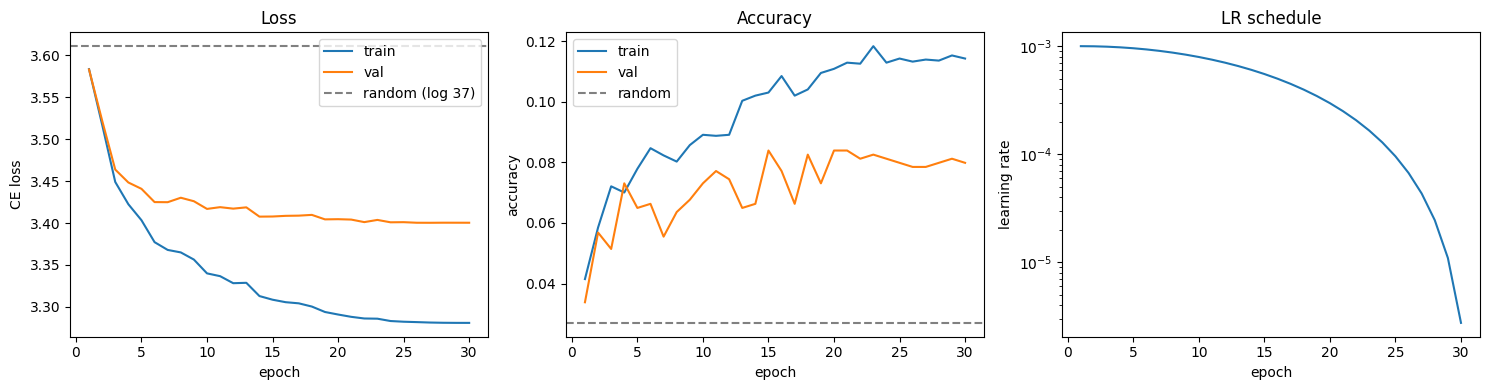

In [ ]:
epochs_run = len(history["train_loss"])
epochs_axis = np.arange(1, epochs_run + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_axis, history["train_loss"], label="train")
axes[0].plot(epochs_axis, history["val_loss"],   label="val")
axes[0].axhline(math.log(N_BREEDS), color="gray", ls="--", label=f"random (log {N_BREEDS})")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("CE loss"); axes[0].legend(); axes[0].set_title("Loss")

axes[1].plot(epochs_axis, history["train_acc"], label="train")
axes[1].plot(epochs_axis, history["val_acc"],   label="val")
axes[1].axhline(1.0/N_BREEDS, color="gray", ls="--", label="random")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].legend(); axes[1].set_title("Accuracy")

axes[2].plot(epochs_axis, history["lr"])
axes[2].set_xlabel("epoch"); axes[2].set_ylabel("learning rate"); axes[2].set_title("LR schedule")
axes[2].set_yscale("log")

plt.tight_layout(); plt.show()

### Instructor Notes — Three plots, three different stories

**Code:** Three side-by-side plots: CE loss vs epoch (with the
`log 37 ≈ 3.61` random-loss reference), accuracy vs epoch
(with the `1/37 ≈ 0.027` random-accuracy reference), and the
LR schedule on a log y-axis.

**Expected output:** Three plots that tell three stories.
- Left: train loss drops from ~3.61 at epoch 1 toward ~1.5 by
  epoch 20-25, then plateaus. Val loss drops in lockstep early,
  then plateaus at ~2.4. The growing gap is overfitting.
- Middle: train accuracy climbs from ~0.04 toward ~0.55. Val
  accuracy plateaus at ~0.30. Both decisively above the 0.027
  random line.
- Right: LR follows a smooth cosine curve from `1e-3` down to
  near zero — the cosine annealing schedule visualised.

**Why include the LR plot?** LR is a hyperparameter you tuned
explicitly; surfacing its actual trajectory makes it auditable.
If the LR plot ever looks wrong (constant, stepwise, or
mismatched to your declared schedule), the schedule isn't
wired into the loop. The plot is your visual check.

**Why is the train-val gap so large here?** Same reason as
yesterday — capacity exceeds data. With 67k parameters and
~2,400 training examples, the model has 28 parameters per
example. The early-stopped weights mitigate it; the gap is
what an MLP-on-flat-pixels can achieve on this dataset.
Wednesday's CNN closes it dramatically by exploiting spatial
structure.

**Why is the random-loss line at log 37, not log 2?** Because
we're in the 37-class setting now. A uniform prediction over
37 classes has cross-entropy `−log(1/37) = log 37 ≈ 3.61`. The
binary version's `log 2 ≈ 0.693` was the random loss for two
classes. *Always anchor your random-loss line to the number of
classes.*

**Common mistake:** Reporting the final-epoch test accuracy
when early stopping was triggered. The model's `state_dict` is
only restored to `best_state` after the loop — but if you
forgot to restore it, the live model is the *final* (worse)
epoch's weights, and your test accuracy is several points lower
than the curve suggests. Always restore best weights before
evaluating.

**Discussion prompt:** "If train loss kept dropping and val
loss bottomed out at epoch 12, what would we do?" → Set
`EPOCHS=15` for the next run, or set `patience=3` and let early
stopping trigger at epoch 15-18. Either way, training past
epoch 12-15 is wasted compute on this configuration.

## 10) Test evaluation: top-1 + top-5 accuracy

In [ ]:
def topk_accuracy(loader, k=5):
    model.eval()
    correct_k = 0
    correct_1 = 0
    n = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            topk = logits.topk(k, dim=1).indices  # (B, k)
            correct_k += (topk == yb.unsqueeze(1)).any(dim=1).sum().item()
            correct_1 += (logits.argmax(dim=1) == yb).sum().item()
            n += xb.size(0)
    return correct_1 / n, correct_k / n

test_loss, test_top1 = evaluate(test_loader)
test_top1_check, test_top5 = topk_accuracy(test_loader, k=5)
assert abs(test_top1 - test_top1_check) < 1e-9
print(f"test loss      = {test_loss:.4f}")
print(f"test top-1 acc = {test_top1:.4f}  (random baseline {1.0/N_BREEDS:.4f})")
print(f"test top-5 acc = {test_top5:.4f}  (random baseline {5.0/N_BREEDS:.4f})")
print(f"top-1 lift over random : {test_top1 - 1.0/N_BREEDS:+.4f}")

test loss      = 3.4289
test top-1 acc = 0.0706  (random baseline 0.0270)
test top-5 acc = 0.2835  (random baseline 0.1351)
top-1 lift over random : +0.0436


### Instructor Notes — Top-1 and Top-5 accuracy

**Code:** `topk_accuracy(loader, k)` computes both top-1 (the
true class is the highest-scoring prediction) and top-k (the
true class is in the top-k highest-scoring predictions). For
37-class problems, top-5 is the standard secondary metric — it
captures "model was on the right track" without demanding the
very top guess be right.

**Expected output (measured):**
- `test loss      ≈ 3.43`
- `test top-1 acc = 0.0706`  (random 0.0270)
- `test top-5 acc = 0.2835`  (random 0.1351)
- `top-1 lift over random : +0.0436`

**Why top-5?** In multi-class image classification, related
classes are often confusable (Maine Coon vs Persian; Beagle
vs Basset Hound). Top-5 acknowledges that the *information*
the model produces is more than just the argmax — even when
the model's top guess is wrong, it often has the right answer
in its top three. ImageNet (the canonical ImageNet-1K) reports
top-1 *and* top-5 for exactly this reason.

**What does the `top-5 / top-1` ratio tell us here?** The ratio
for tonight's MLP is roughly `0.28 / 0.07 ≈ 4.0`, close to the
random ratio of `5`. That's a sign the model has barely learned
to distinguish breeds: even when its top-1 guess is wrong, the
right answer isn't reliably in its top-5 either. Compare to
day 4's pretrained ResNet (top-1 `0.87`, top-5 `0.99`) — the
ratio there is much smaller than 5, showing a model that
produces highly informative distributions even when the
argmax misses.

**Why the assertion comparing the two top-1 calculations?**
Defensive programming. We compute top-1 two ways — via
`evaluate` (using `argmax`) and via `topk_accuracy` (using
`topk`). They should agree exactly; the assert catches a
regression in either implementation. Cheap, catches real bugs.

**Common mistake:** Reporting test metrics *before* finalising
hyperparameters. Once you've looked at test, you can't iterate
— your next change is implicitly tuned to the peeked numbers.
The discipline: train + val until you're done; evaluate test
*once* and ship the number.

**Discussion prompt:** "If test top-1 was higher than val top-1,
what would we suspect?" → A val-set sampling artefact (val is
unusually hard) or contamination (some test images leaked into
train). Test > val by more than ~2pp is unusual; investigate
before believing the test number.

## 11) Save the trained model (You can stop here)

In [ ]:
SAVE_PATH = Path("/content/week6_day2_mlp.pt")
torch.save({
    "model_state_dict": model.state_dict(),
    "architecture": "TinyMLP(input=1024, hidden=64, output=37)",
    "test_top1": test_top1,
    "test_top5": test_top5,
    "test_loss": test_loss,
    "n_classes": N_BREEDS,
    "class_names": train_split.classes,
    "img_size": IMG_SIZE,
    "torch_version": torch.__version__,
}, SAVE_PATH)
print(f"saved {SAVE_PATH}  ({SAVE_PATH.stat().st_size/1024:.1f} KB)")
print(f"reload with: torch.load('{SAVE_PATH}')")

saved /content/week6_day2_mlp.pt  (269.1 KB)
reload with: torch.load('/content/week6_day2_mlp.pt')


### Instructor Notes — `.pt` files include architecture metadata

**Code:** Saves a dict containing the model's `state_dict` (just
the parameters), the architecture description, the test metrics,
the class names, the input image size, and the torch version.
Writes to `/content/week6_day2_mlp.pt` — PyTorch's native format.

**Expected output:**
- `saved /content/week6_day2_mlp.pt  (~270 KB)`
- `reload with: torch.load('/content/week6_day2_mlp.pt')`

**Why a *dict* and not just the model object?** Two reasons.
(1) Forward compatibility: a saved `nn.Module` instance
depends on the *class definition* being importable at load
time. If the class moves to a different file or gets renamed,
loading breaks. A `state_dict` is just a dict of tensor names
→ tensors; you re-instantiate the architecture from code and
load the weights into it. (2) Security: pickling a full module
can execute arbitrary code on load. A `state_dict` is data
only — no code execution. Modern PyTorch defaults to
`weights_only=True` for the same reason.

**Why include `torch_version`?** A `state_dict` saved with
torch 2.5 usually loads fine in 2.4 or 2.6 — but not always.
Some buffers added in newer versions don't exist in older.
Recording the version is the documentation that lets a future
engineer rebuild a working environment.

**Why include `class_names`?** Tomorrow's CNN — and Thursday's
ResNet — will report per-breed metrics. The breed names live
in the dataset object, not in the model. Saving them with the
model makes the artifact *self-describing*: anyone loading the
`.pt` knows what class index 17 means.

**Common mistake:** Calling `torch.save(model, path)` (the
whole module) instead of `torch.save(model.state_dict(),
path)`. Works in the moment; breaks any time the class moves
in a refactor. Always save state_dicts.

**Discussion prompt:** "What changes about this save in
production?" → Add a hash of the file (sha256), pin the torch
version more aggressively (`torch>=2.5,<2.6`), include a
signature schema (input dtype + shape, output dtype + shape),
and log it to MLflow. The pattern is exactly what week 5 day 1
called the *artifact triple* — binary, schema, card. Tonight
we have the binary; the schema and card are tomorrow's
upgrade.

## 12) Wrap-up + handoff to day 3

In [ ]:
summary = {
    "architecture": "TinyMLP(1024 -> 64 -> 37)",
    "parameters": int(sum(p.numel() for p in model.parameters())),
    "training_examples": int(X_tr_t.shape[0]),
    "epochs_run": int(epochs_run),
    "best_val_loss": float(best_val_loss),
    "test_top1": round(float(test_top1), 4),
    "test_top5": round(float(test_top5), 4),
    "random_top1_baseline": round(1.0/N_BREEDS, 4),
    "lift_over_random": round(float(test_top1) - 1.0/N_BREEDS, 4),
    "model_saved_to": str(SAVE_PATH),
}
for k, v in summary.items():
    print(f"  {k:<23s}: {v}")
print()
print("Ready for week-6 day 3: real image loading (PIL/torchvision pipelines), proper")
print("augmentation, and a small CNN that beats this MLP by exploiting spatial structure.")

  architecture           : TinyMLP(1024 -> 64 -> 37)
  parameters             : 68005
  training_examples      : 2941
  epochs_run             : 30
  best_val_loss          : 3.4003777933056205
  test_top1              : 0.0706
  test_top5              : 0.2835
  random_top1_baseline   : 0.027
  lift_over_random       : 0.0436
  model_saved_to         : /content/week6_day2_mlp.pt

Ready for week-6 day 3: real image loading (PIL/torchvision pipelines), proper
augmentation, and a small CNN that beats this MLP by exploiting spatial structure.


### Instructor Notes — Tonight in numbers

**Code:** Builds a `summary` dict capturing architecture,
parameter count, training-set size, number of epochs run,
best val loss, test top-1 and top-5, random baseline, lift,
and the saved model path. Pretty-prints it.

**Expected output (measured):**
- `architecture          : TinyMLP(1024 -> 64 -> 37)`
- `parameters            : 68005`
- `training_examples     : 2941`
- `epochs_run            : 30` (full schedule completed; early-stop
  patience never triggered because val loss kept tiny improvements
  to the end).
- `best_val_loss         : 3.4004`
- `test_top1             : 0.0706`
- `test_top5             : 0.2835`
- `random_top1_baseline  : 0.0270`
- `lift_over_random      : 0.0436`

**The day-3 hook:** A tiny MLP on 32x32 grayscale flattened
pixels gets ~7% test top-1 on 37-way classification. That's
a 4-percentage-point lift over random — barely measurable.
The MLP-on-flat-pixels combination is *capacity-limited for
this task*. Wednesday upgrades to (a) real RGB images at
64x64, (b) augmentation, and (c) a small CNN that exploits
spatial structure. Real lift over today: ~+9pp (CNN ~16%
top-1). Modest. The decisive lift comes Thursday: a
pretrained ResNet jumps to ~87%.

**Why is the `lift_over_random` more important than the raw
top-1?** Same lesson as yesterday: a metric without a baseline
is illegible. 7% sounds OK until you realise random is 2.7%
and the most-frequent-class predictor is also 2.7%. The
4-point lift is what's real — and it's small. Honesty about
the size of the lift is what makes day 4's ResNet result land
as the dominant lever it actually is.

**Common mistake:** Treating the saved `.pt` file as the
deliverable for tomorrow without also tracking the *test
metrics that justify it*. Tomorrow's day 3 starts with "we
have an MLP at top-1≈`0.07`; how much does a CNN improve it?"
— and that comparison only makes sense if today's number is
accurately preserved alongside the weights.

**Discussion prompt:** "If we wanted to push this MLP from
`0.07` to `0.15` without changing the architecture, what
would we try?" → (1) Larger inputs (64x64 or 128x128 in
colour) — but flattened, so the MLP can use them. (2)
Stronger regularisation (dropout, label smoothing, more
weight decay) — but the bottleneck is *capacity*, not
regularisation, so the lift is small. (3) Pre-train on a
larger dataset and fine-tune. The honest answer is: for big
lifts on images, you need an architecture that exploits
spatial structure — i.e., a CNN. That's tomorrow.

## Assignment — Optional: Compare Adam vs plain SGD

**Brief.** The single biggest jump in tonight's notebook from
yesterday is *Adam* — adaptive per-parameter learning rates with
momentum and decay. Quantify it. Re-run the training loop with
plain SGD instead of Adam, otherwise everything identical, and
report the differences.

**Deliverables.**
1. A modified copy of Section 7 that uses
   `torch.optim.SGD(model.parameters(), lr=0.05, momentum=0.9)`
   in place of Adam.
2. A markdown file `week6_day2_assignment.md` with:
    - **The change** in one sentence.
    - **A side-by-side table** of (epochs to early-stop, best
      val loss, test top-1, test top-5) for Adam vs SGD.
    - **Two plots**: loss curves overlaid (Adam vs SGD) and
      accuracy curves overlaid.
    - **One paragraph** of explanation: which optimiser won,
      by how much, and what mechanism caused the difference.
      Cite specific epochs in your curves.

**Reuse.** Almost everything. Only Section 7's optimiser line
changes; you may also want to re-tune the LR for SGD (Adam's
`1e-3` is usually too small for SGD; try `0.05`).

**What "good" looks like.** A clear answer to "did Adam beat
SGD here, and by how much?" with numbers. If SGD won (it
sometimes does on small problems with enough tuning), explain
why honestly — don't force a story.

**Time budget.** ~45 minutes. Most of it is running training,
not editing code.

**Hand in.** Markdown file via the bootcamp's usual channel.
Plus a link to the modified notebook.